# Лабораторная работа №8
# "EuroSAT"

ЦЕЛЬ РАБОТЫ -  классифицировать спутниковые изображения из набора данных EuroSAT (10 классов)

РЕШАЕМАЯ ЗАДАЧА - разработать модель, способную автоматически классифицировать спутниковые снимки Sentinel-2 из набора EuroSAT, относя каждое изображение к одному из десяти классов (таких как лес, пастбище, ежегодные культуры, водоёмы, жилые здания и др.).

ХОД РАБОТЫ

1) Взять набор данных EuroSAT https://github.com/phelber/EuroSAT.
2) Взять любую предобученную нейронную сеть классификации изображений.
- Не предобученную на EuroSAT ._.

3) Заморозить выбранную сеть, убрать оригинальные слои классификации, добавить новые размороженные слои.
4) Обучить новые слои для классификации на EuroSAT.
5) Продемонстрировать результаты.

ОПИСАНИЕ ДАННЫХ

В этом исследовании мы решаем задачу классификации землепользования и растительного покрова с использованием спутниковых снимков Sentinel-2. Спутниковые снимки Sentinel-2 находятся в открытом и бесплатном доступе и предоставляются в программе наблюдения Земли Copernicus. Мы представляем новый набор данных, основанный на спутниковых снимках Sentinel-2, охватывающих 13 спектральных каналов и состоящих из 10 классов с общим количеством 27 000 маркированных и геопривязанных изображений. Мы предоставляем контрольные показатели для этого нового набора данных с его спектральными каналами, используя современную глубокую сверточную нейронную сеть (CNN). С предлагаемым новым набором данных мы достигли общей точности классификации 98,57%. Полученная система классификации открывает путь к ряду приложений для наблюдения Земли. Мы демонстрируем, как эта система классификации может быть использована для обнаружения изменений землепользования и растительного покрова и как она может помочь в улучшении географических карт.

## Импорт необходимых пакетов

P.s ниже я проверяю используется ли GPU при обучении)

In [1]:
import tensorflow as tf
# print(tf.config.list_physical_devices('GPU'))

In [2]:
# !nvidia-smi

In [3]:
# import tensorflow as tf
# tf.debugging.set_log_device_placement(True)

# a = tf.random.normal((1000, 1000))
# b = tf.random.normal((1000, 1000))
# c = tf.matmul(a, b)
# print(c)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

## Загрузка данных

Для начала посмотрим на сами изображения, возьмем по одному снимку из каждого класса)

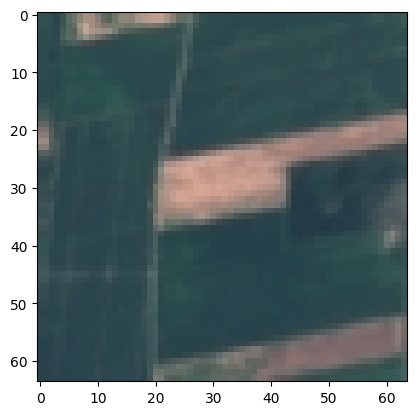

In [5]:
image = Image.open('2750/AnnualCrop/AnnualCrop_271.jpg')
plt.imshow(np.array(image))

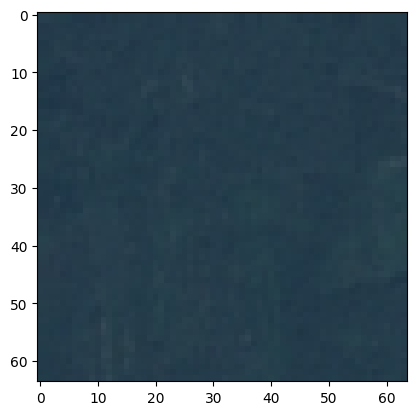

In [6]:
image = Image.open('2750/Forest/Forest_271.jpg')
plt.imshow(np.array(image))

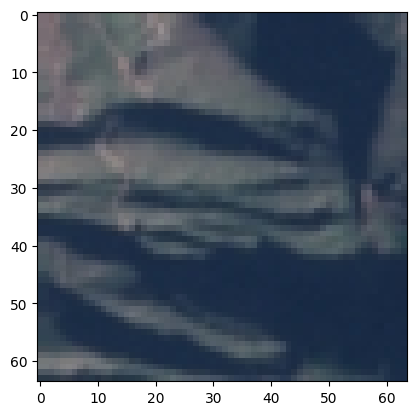

In [7]:
image = Image.open('2750/HerbaceousVegetation/HerbaceousVegetation_271.jpg')
plt.imshow(np.array(image))

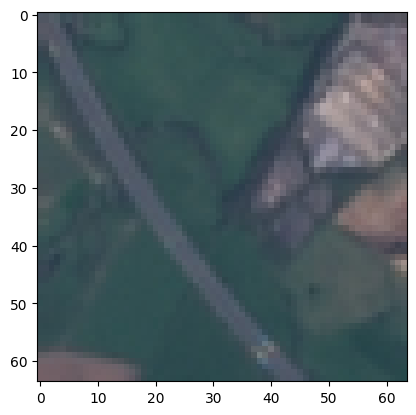

In [8]:
image = Image.open('2750/Highway/Highway_271.jpg')
plt.imshow(np.array(image))

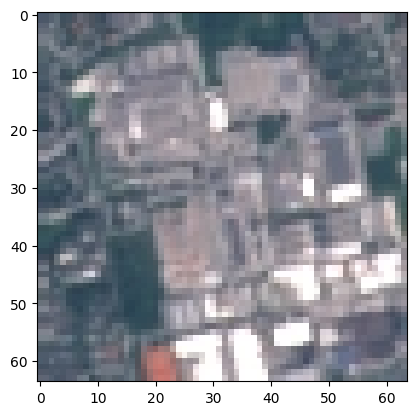

In [9]:
image = Image.open('2750/Industrial/Industrial_271.jpg')
plt.imshow(np.array(image))

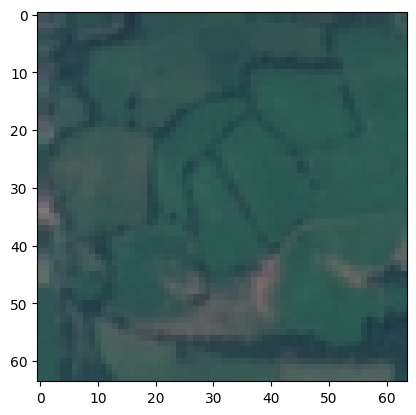

In [10]:
image = Image.open('2750/Pasture/Pasture_271.jpg')
plt.imshow(np.array(image))

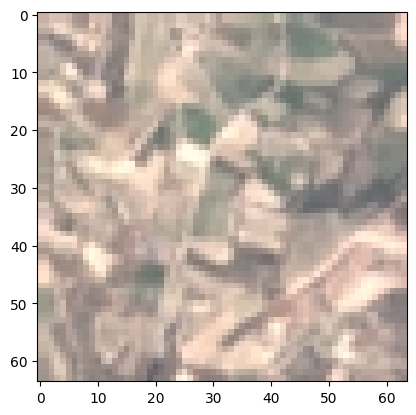

In [11]:
image = Image.open('2750/PermanentCrop/PermanentCrop_271.jpg')
plt.imshow(np.array(image))

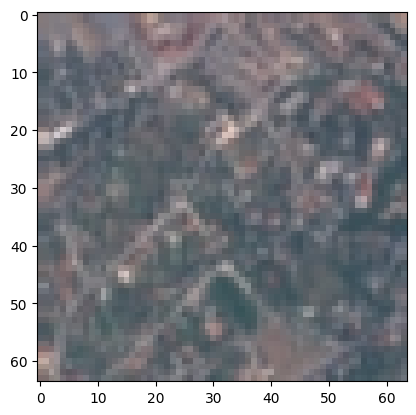

In [12]:
image = Image.open('2750/Residential/Residential_271.jpg')
plt.imshow(np.array(image))

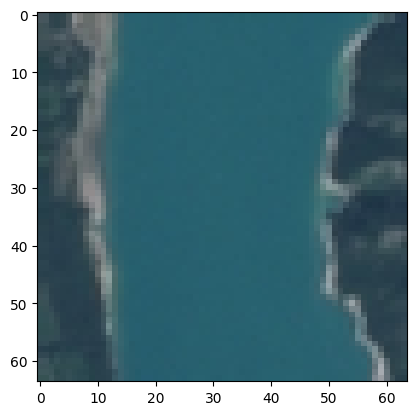

In [13]:
image = Image.open('2750/River/River_271.jpg')
plt.imshow(np.array(image))

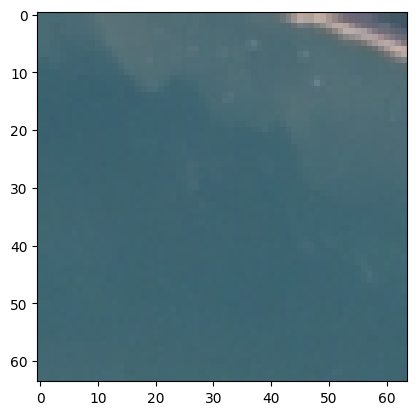

In [14]:
image = Image.open('2750/SeaLake/SeaLake_271.jpg')
plt.imshow(np.array(image))

Данные выгружены и отображаются корректно)

В библиотеке Keras есть удобный загрузчик ImageDataGenerator (англ. «генератор данных изображений»): 

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Из изображений в папках класс ImageDataGenerator формирует батчи с изображениями и метками классов:

In [16]:
datagen = ImageDataGenerator() 

Чтобы загрузчик извлёк данные из папки, вызовем метод flow_from_directory() 

In [17]:
datagen_flow = datagen.flow_from_directory(
    # папка, в которой хранится датасет
    '2750/',
    target_size=(224, 224), 
    batch_size=16,
    class_mode='sparse',
    seed=12345)

Found 24304 images belonging to 10 classes.


Загрузчик нашёл 10 классов (папок), всего в них 24304 изображений.

Значения некоторых аргументов:
- target_size=(224, 224) — аргумент с шириной и высотой, к которым будут приводиться изображения. В папках могут лежать изображения разного размера, а нейронным сетям нужно, чтобы все изображения были одинаковые.
- batch_size=16 — количество изображений в батче. Чем больше изображений, тем лучше обучится сеть. Много сников в памяти GPU не поместится, поэтому 16 — это золотая середина, с которой можно стартовать.
- сlass_mode='sparse' — аргумент, который указывает тип выдачи метки классов. sparse (англ. «редкий») означает, что метки будут порядковым номером папки.

Узнаем, как номера классов связаны с названиями папок:

In [18]:
print(datagen_flow.class_indices)

{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


Применим метод datagen.flow_from_directory(...), получите объект, у которого пары «картинки — метки» можно получить функцией next() (англ. «следующий»):

In [19]:
features, target = next(datagen_flow)

print(features.shape)

(16, 224, 224, 3)


Получились признаки — четырёхмерный тензор, в котором 16 изображений размером 224x224 с тремя цветовыми каналами.

Чтобы обучить на этих данных модель, передадим объект datagen_flow в метод fit(). Эпоха не должна быть бесконечно длинной. Для этого укажем в параметре steps_per_epoch количество батчей в наборе данных:

In [20]:
# model.fit(datagen_flow, steps_per_epoch=len(datagen_flow))

В методе fit() должна быть не только обучающая, но и валидационная выборка. Для этого создадим два загрузчика: для обучающей и валидационной.

ВАЖНАЯ ЗАМЕТКА, я создала ОТДЕЛЬНО папку с ТЕСТОВОЙ ВЫБОРКОЙ, стостоящую из 2700 изображений(270 изображений на 1 класс)

In [21]:
# указываем загрузчику, что валидация содержит 
# 25% случайных объектов
datagen = ImageDataGenerator(validation_split=0.25)

train_datagen_flow = datagen.flow_from_directory(
    '2750/',
    target_size=(224, 224),
    batch_size=16,
    class_mode='sparse',
    # указываем, что это загрузчик для обучающей выборки
    subset='training',
    seed=12345)

val_datagen_flow = datagen.flow_from_directory(
    '2750/',
    target_size=(224, 224),
    batch_size=16,
    class_mode='sparse',
    # указываем, что это загрузчик для валидационной выборки
    subset='validation',
    seed=12345)

Found 18233 images belonging to 10 classes.
Found 6071 images belonging to 10 classes.


Теперь обучение запускается так:

In [22]:
# model.fit(train_datagen_flow,
#           validation_data=val_datagen_flow,
#           steps_per_epoch=len(train_datagen_flow),
#           validation_steps=len(val_datagen_flow))

## ResNet50

Импортируем ResNet из Keras. 50 означает количество слоёв в сети.

In [23]:
from tensorflow.keras.applications.resnet import ResNet50
# tf.debugging.set_log_device_placement(False) # чтобы логи не вылазили
model = ResNet50(input_shape=None,
                 classes=1000,
                 include_top=True,
                 weights='imagenet')

 Аргументы:
- input_shape — размер входного изображения. Например: (640, 480, 3).
- classes=1000 — количество нейронов в последнем полносвязном слое, в котором выполняется классификация.
- weights='imagenet' (от англ. «сеть изображений») — инициализация весов. ImageNet — название большого датасета, на котором сеть обучалась классифицировать изображения на 1000 классов. Если обучение сети начать на ImageNet, а продолжить на вашей задаче, результат будет лучше, чем если обучать с нуля. Чтобы инициализация весов была случайной, напишите weights=None.
- include_top=True (англ. «добавить верхушку») — указание на то, что в конце архитектуры ResNet есть два слоя: GlobalAveragePooling2D и Dense. Если задать False, то этих слоёв не будет.

Последние слои:

1) GlobalAveragePooling2D (англ. «глобальный двумерный пулинг усреднением») — пулинг с окном во весь тензор. Как и AveragePooling2D, возвращает среднее значение из группы пикселей внутри канала. GlobalAveragePooling2D нужен, чтобы усреднить информацию по всему изображению, то есть получить пиксель с большим количеством каналов (например, 512 для ResNet50).
2) Dense — полносвязный слой для классификации.

Посмотрим, как применить предобученную на ImageNet сеть. Чтобы адаптировать ResNet50 к задаче, уберем верхушку и сконструируем её заново:

где backbone (англ. «костяк») — то, что осталось от ResNet50.

Допустим, есть очень маленький датасет: всего 100 картинок и два класса. Если на таком датасете обучить ResNet50, то она гарантированно переобучится: в ней слишком много параметров — порядка 23 млн! У сети будут идеальные предсказания на обучающей выборке и случайные — на тестовой.

Чтобы этого избежать, «заморозим» часть сети: если некоторые слои оставить с весами из ImageNet, они не будут обучаться градиентным спуском. Обучим только 1–2 полносвязных слоя наверху сети. Так количество параметров в сети уменьшится, но архитектура сохранится.
Вот реализация:

In [24]:
backbone = ResNet50(input_shape=(224, 224, 3),
                    weights='imagenet', 
                    include_top=False)

# замораживаем ResNet50 без верхушки
backbone.trainable = False

model = Sequential()
model.add(backbone)
model.add(GlobalAveragePooling2D())
model.add(Dense(10, activation='softmax'))

Чтобы сеть обучалась, добавленный сверху backbone полносвязный слой замораживать не стали.
Заморозка позволяет избавиться от переобучения и повысить скорость обучения сети:  градиентному спуску считать производные для замороженных слоёв не нужно.

In [25]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['acc'])

In [26]:
history = model.fit(train_datagen_flow,
          validation_data=val_datagen_flow,
          steps_per_epoch=len(train_datagen_flow),
          validation_steps=len(val_datagen_flow), 
          epochs = 10, verbose=2)

Epoch 1/10
1140/1140 - 123s - loss: 0.3132 - acc: 0.8971 - val_loss: 0.1889 - val_acc: 0.9351 - 123s/epoch - 108ms/step
Epoch 2/10
1140/1140 - 118s - loss: 0.1739 - acc: 0.9404 - val_loss: 0.1657 - val_acc: 0.9435 - 118s/epoch - 103ms/step
Epoch 3/10
1140/1140 - 118s - loss: 0.1460 - acc: 0.9497 - val_loss: 0.1627 - val_acc: 0.9422 - 118s/epoch - 103ms/step
Epoch 4/10
1140/1140 - 118s - loss: 0.1287 - acc: 0.9554 - val_loss: 0.1585 - val_acc: 0.9463 - 118s/epoch - 103ms/step
Epoch 5/10
1140/1140 - 118s - loss: 0.1181 - acc: 0.9598 - val_loss: 0.1319 - val_acc: 0.9555 - 118s/epoch - 104ms/step
Epoch 6/10
1140/1140 - 118s - loss: 0.1082 - acc: 0.9638 - val_loss: 0.1339 - val_acc: 0.9539 - 118s/epoch - 104ms/step
Epoch 7/10
1140/1140 - 118s - loss: 0.1026 - acc: 0.9649 - val_loss: 0.1176 - val_acc: 0.9603 - 118s/epoch - 103ms/step
Epoch 8/10
1140/1140 - 118s - loss: 0.0970 - acc: 0.9671 - val_loss: 0.1152 - val_acc: 0.9624 - 118s/epoch - 104ms/step
Epoch 9/10
1140/1140 - 118s - loss: 0.09

## Отображение результатов обучения

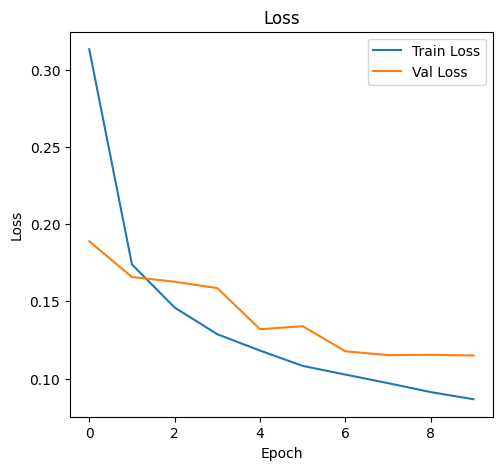

In [27]:
# График потерь
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

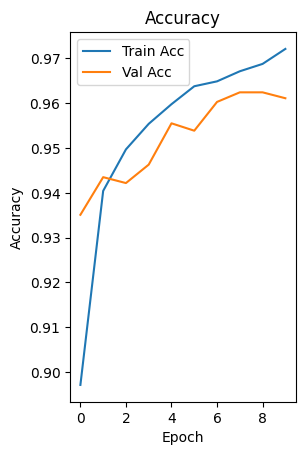

In [28]:
# График точности
plt.subplot(1,2,2)
plt.plot(history.history['acc'], label='Train Acc')
plt.plot(history.history['val_acc'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

По графикам видно, что обучение прошло очень хорошо, Train loss: уменьшается от 0.3132 → 0.0866 за 10 эпох → значит, модель учится и хорошо подгоняет данные обучающего набора. Val loss: уменьшилась от 0. 0.1889 → 0.1149 → значит, модель не переобучается, а генерализуется на валидацию. 

Train acc: растёт от 0.9028 → 0.9707 → модель очень хорошо классифицирует обучающие данные. Val acc: растёт от 0.9351 → 0.9611 → модель хорошо работает и на новых данных. Разрыв между train и val невелик (~97% vs 96%) → переобучение минимально.

P.s продлила до 12 эпох, но точность на валидации упала, поэтому оставила 10 эпох)

Возьмем предсказания с тестовой выборки

In [29]:
datagen = ImageDataGenerator() 
test_datagen_flow = datagen.flow_from_directory(
    # папка, в которой хранится тестовая выборка
    'test/',
    target_size=(224, 224), 
    batch_size=16,
    class_mode='sparse',
    seed=12345)

Found 2700 images belonging to 10 classes.


In [31]:
test_loss, test_acc = model.evaluate(test_datagen_flow)
print("Test accuracy:", test_acc)

169/169 [==============================] - 14s 82ms/step - loss: 0.1244 - acc: 0.9596
Test accuracy: 0.9596296548843384


In [32]:
images, labels = next(test_datagen_flow)
preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)
class_names = list(test_datagen_flow.class_indices.keys())

1/1 [==============================] - 1s 831ms/step


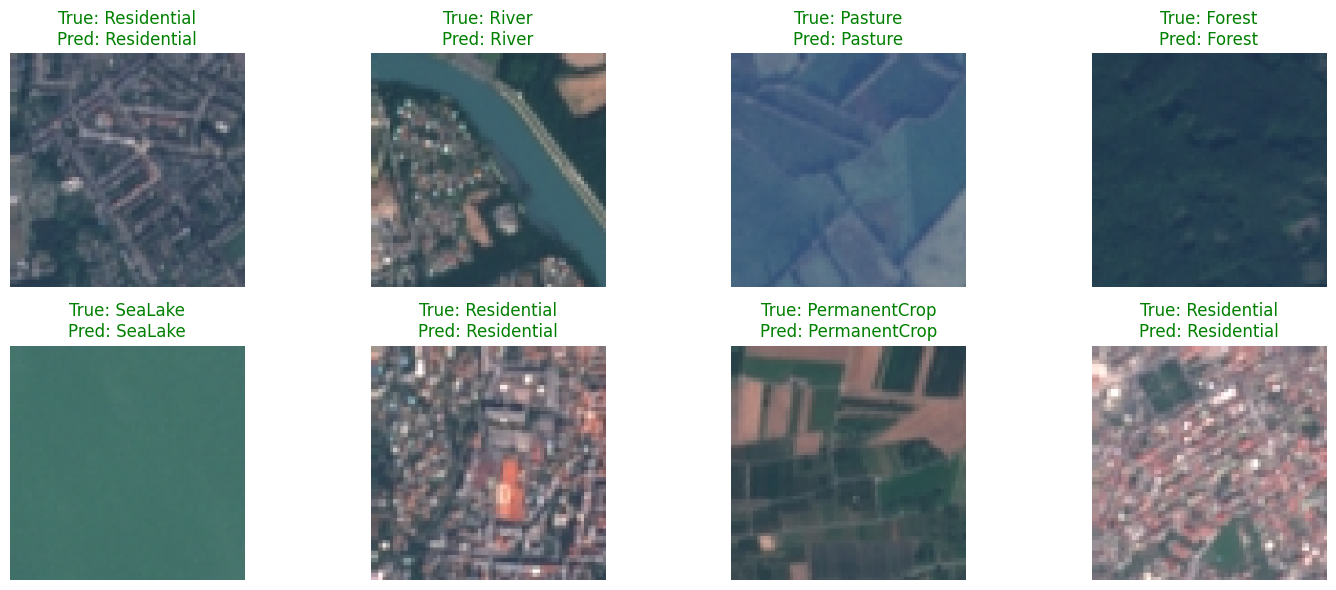

In [33]:
plt.figure(figsize=(15,6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].astype('uint8'))
    true_label = class_names[int(labels[i])]
    pred_label = class_names[pred_classes[i]]
    color = 'green' if labels[i] == pred_classes[i] else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

По результатам оценки метрики на тестовой выборке и графикам точности и потерь можно сказать об успешном обучении модели. Модель показала отличную точность - Test accuracy: 0.9596296548843384 на независимой тестовой выборке (2700 изображений, брались первые 270 снимков с каждого класска).

## Общий вывод

В ходе лабораторной работы была реализована классификация спутниковых изображений из датасета EuroSAT с использованием предобученной нейронной сети ResNet50. Модель была загружена без верхней классификационной части, все её исходные слои заморожены, а вместо оригинальных классификаторов добавлены новые обучаемые слои, адаптированные под 10 классов EuroSAT. После обучения новых слоёв на тренировочной выборке модель показала высокие результаты: точность на валидации составила примерно 96%, а на независимой тестовой выборке из 2700 изображений — около 95.96%. Это демонстрирует эффективность подхода transfer learning для задач анализа спутниковых снимков и подтверждает, что предобученные архитектуры позволяют достичь высокой точности даже при ограниченном количестве специализированных данных.

Работа выполнена Гареевой Д.Р (507540), j4150